In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, '../../..')
from attn_bench.plotting import model_registry
from attn_bench.plotting.data_loading import load_attention_patterns, load_attention_gating
from attn_bench.plotting.attention_patterns import (
    plot_first_token_attention_avg, plot_first_token_attention_by_bucket,
    plot_map, plot_bucket_maps, plot_full_attn_maps_panel, plot_gating_distribution,
)
from attn_bench.plotting.rouge_l import plot_mem_bucket_counts

## Attention pattern analysis
All main attentions: **full**, **gated**, **off-by-one**, **sink**.
**GDN** does not have attention patterns.

Capture is averaged into 10 Rouge-L buckets (`00-01` … `09-10`) aggregated across all
repetition buckets. Each file holds a full causal map `[L, H, S, S]` (query × key),
`S = prefix + suffix - 1`. Maps are raw (not renormalized): attention to the first token
is column 0, and the virtual-sink mass of sink/obo models is `1 - row sum`.

- Prefix / suffix: 50 / 50 tokens
- Models with missing files are skipped automatically.

## Setup
Paths, model list, and capture parameters, then load the bucketed `attn_scores` maps.

In [ ]:
EXP_BASE = model_registry.MEM_RESULTS_DIR_OLD

MODELS = {
    'full':       'llama3-1b-full-attn-scf8-fineweb40B-gutenberg3B-scf1',
    'gated':      'llama3-1b-gated-attn-scf8-fineweb40B-gutenberg3B-scf1',
    'off-by-one': 'llama3-1b-off-by-one-attn-scf8-fineweb40B-gutenberg3B-te215-scf1',
    'learn-sink': 'llama3-1b-sink-attn-scf8-fineweb40B-gutenberg3B-te215-scf1',
}

OFFSET, PREFIX_LEN, SUFFIX_LEN = 0, 50, 50

In [ ]:
# Full causal attention maps, per model, all Rouge-L buckets ({} = no files yet)
attn = {
    key: load_attention_patterns(EXP_BASE, name, 'attn_scores', OFFSET, PREFIX_LEN, SUFFIX_LEN)
    for key, name in MODELS.items()
}

print('attn_scores availability per model:')
for key, buckets in attn.items():
    n = sum(int(v['count']) for v in buckets.values())
    print(f'  {key:6s}: {len(buckets)}/10 buckets, {n} samples total')

## Data coverage: Rouge-L bucket sizes
How many samples landed in each of the 10 Rouge-L buckets, per model

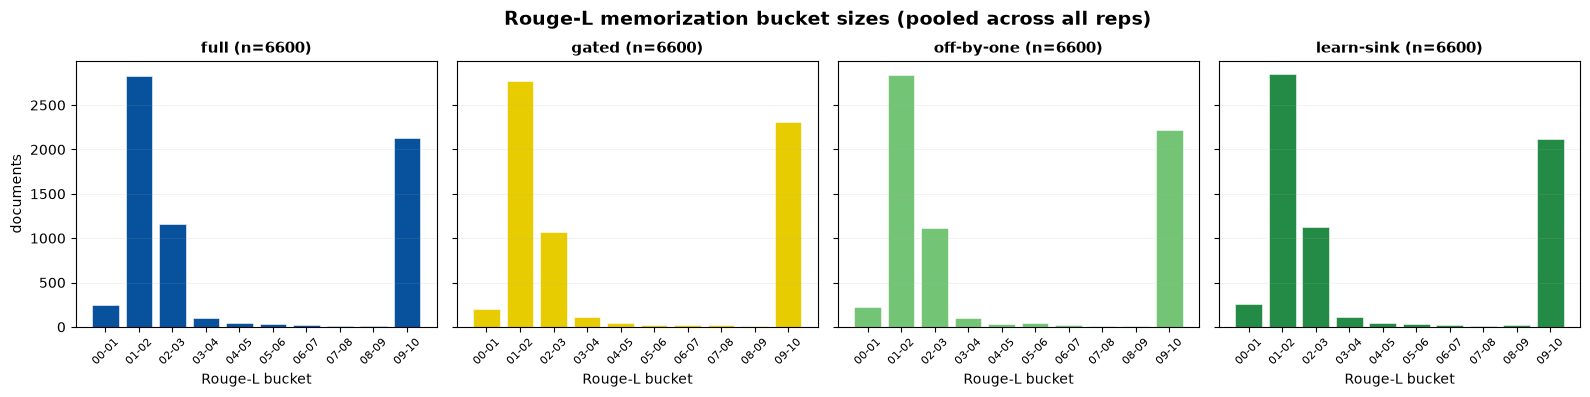

In [20]:
plot_mem_bucket_counts(attn)

## Attention sinks: attention to token 0
Mean attention to the **first token** (key position 0) per layer, averaged over heads and
query positions.
Note: early query rows see very few keys, so they inflate attention to key 0. Pass
`query_slice=slice(PREFIX_LEN, None)` to restrict to decode rows and remove that boundary
effect.

### Averaged over all mem buckets

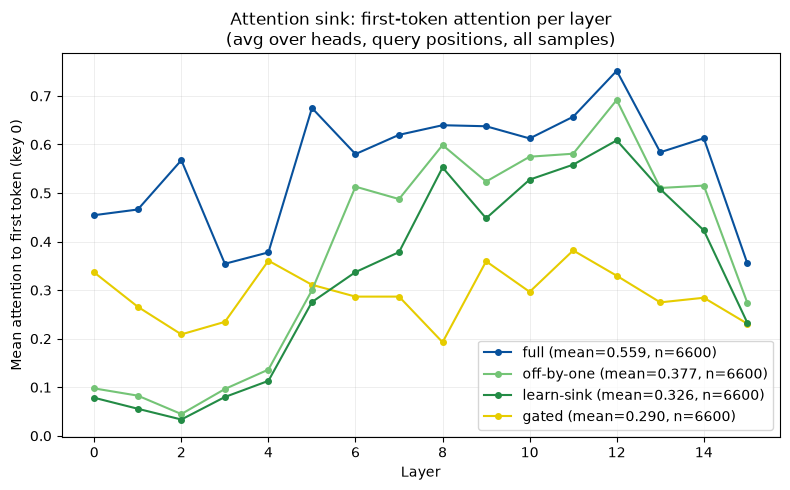

In [24]:
plot_first_token_attention_avg(
    attn,
    query_slice=slice(25)
)
plt.show()

### Split into mem buckets

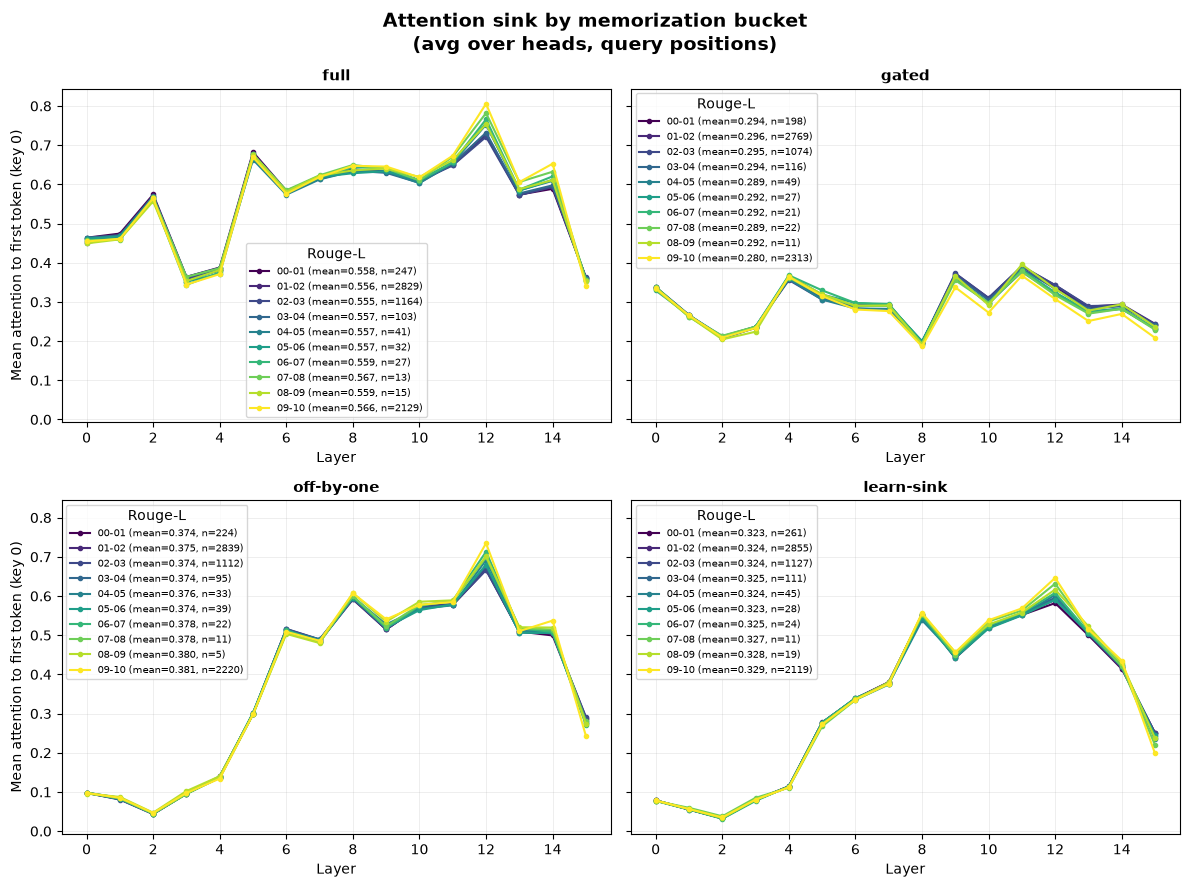

In [25]:
plot_first_token_attention_by_bucket(
    attn,
    query_slice=slice(25)
)
plt.show()

---
## Attention maps: high vs low memorization
For a chosen `layer` / `head`, one heatmap per mechanism (query × key, log scale).
Pick a Rouge-L bucket: `'09-10'` = strongly memorized, `'00-01'` = not memorized.
`n=` in each panel title is how many samples landed in that bucket.

no maps for bucket 02-01 in any model


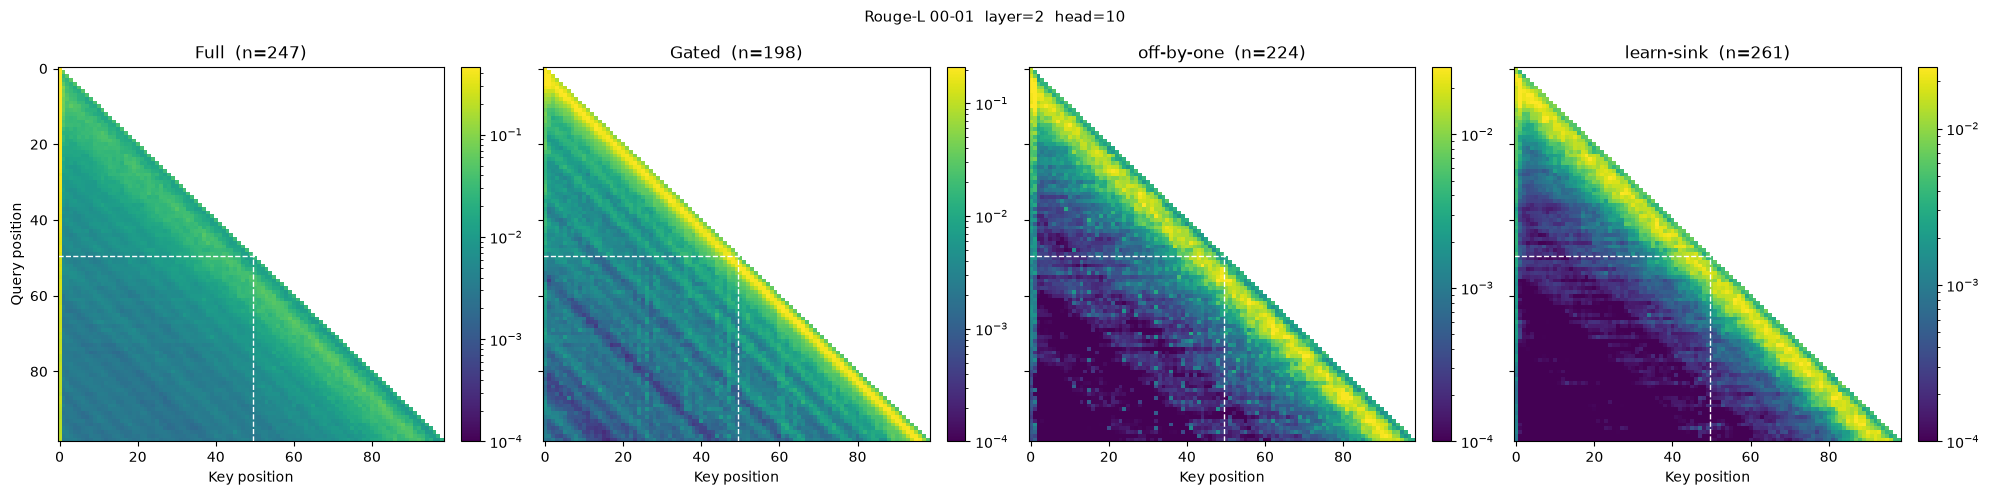

In [36]:
# Early layers show the biggest difference in attention sinks
LAYER=2
# 10, 20
# layer 2, head 10 -- only full attention shows attention sink; however, for other heads its nto always the case
HEAD=10
plot_bucket_maps(attn, bucket='02-01', layer=LAYER, head=HEAD)
plot_bucket_maps(attn, bucket='00-01', layer=LAYER, head=HEAD)
plt.show()

---
## Full panel: every head x layer
Every (layer, head) attention map at once, for one Rouge-L bucket -- rows: layer x model,
cols: head. Tiny cells -- spot outliers here, then zoom in with plot_map / plot_bucket_maps
above. `models`/`heads`/`layers` narrow it down for a readable side-by-side comparison
instead of the full grid.

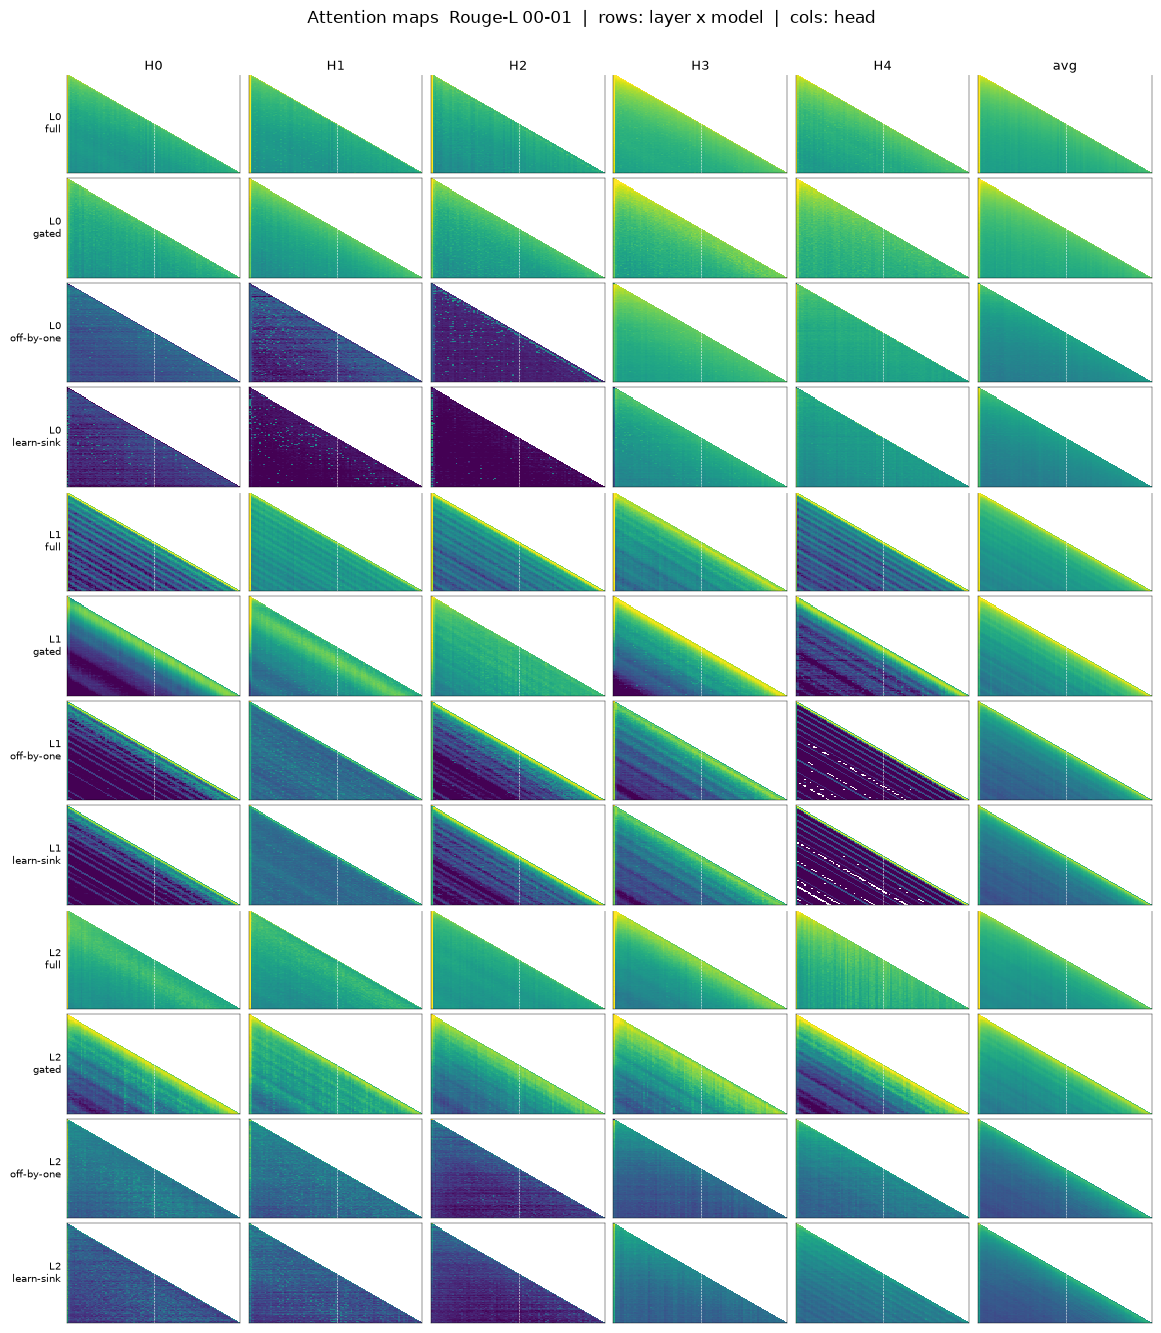

In [57]:
bucket = '09-10'  # strongly memorized
bucket = '00-01'  # barely memorized
maps = {name: b[bucket] for name, b in attn.items() if bucket in b}
plot_full_attn_maps_panel(
    maps, bucket=bucket,
    # models=['full', 'learn-sink'],
    heads=[0, 1, 2, 3, 4],
    layers=[0, 1, 2],
)
plt.show()

---
## Gating-score distribution (gated model)
Normalized density of the output-gate value `sigmoid(gate)`, pooled over **all layers,
heads, positions and samples**, one curve per Rouge-L bucket — does the gated model gate
differently for memorized vs non-memorized text? (Gated model only.)

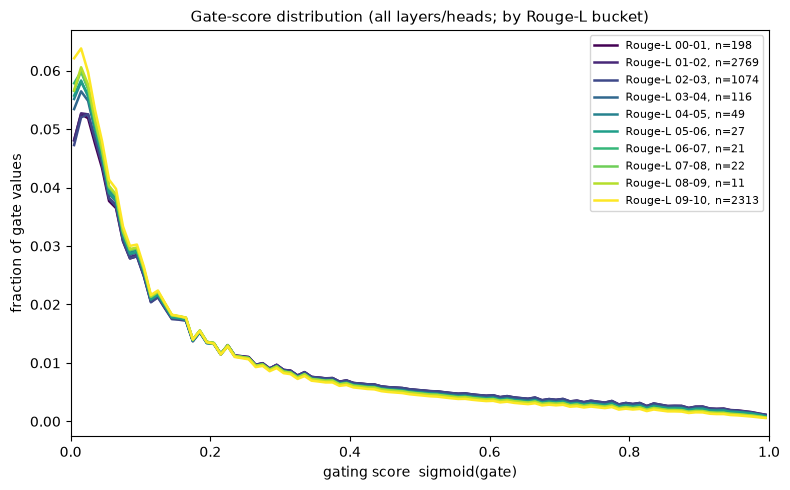

In [51]:
gating = load_attention_gating(EXP_BASE, MODELS['gated'], OFFSET, PREFIX_LEN, SUFFIX_LEN)

# all 10 Rouge-L buckets as a memorization gradient
plot_gating_distribution(gating, buckets=range(0, 10))
plt.show()